<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Day_58_59__Ridge_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

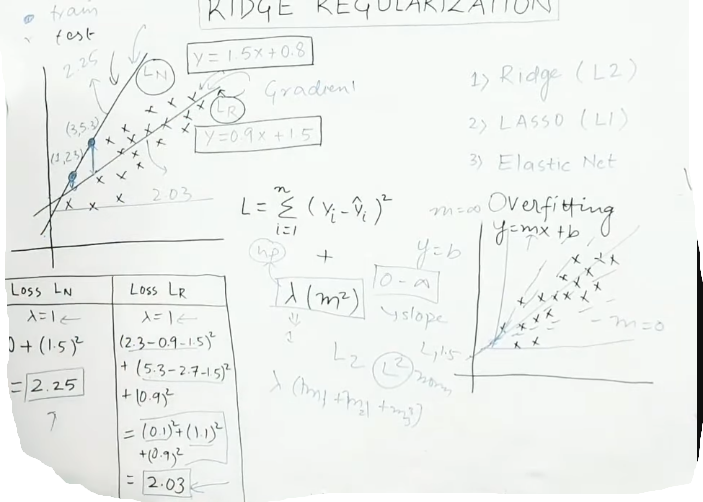

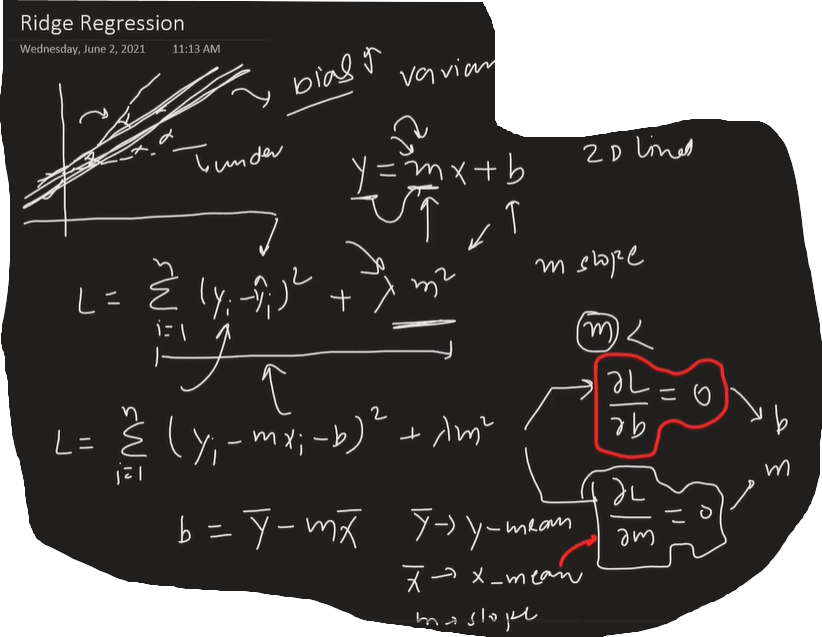

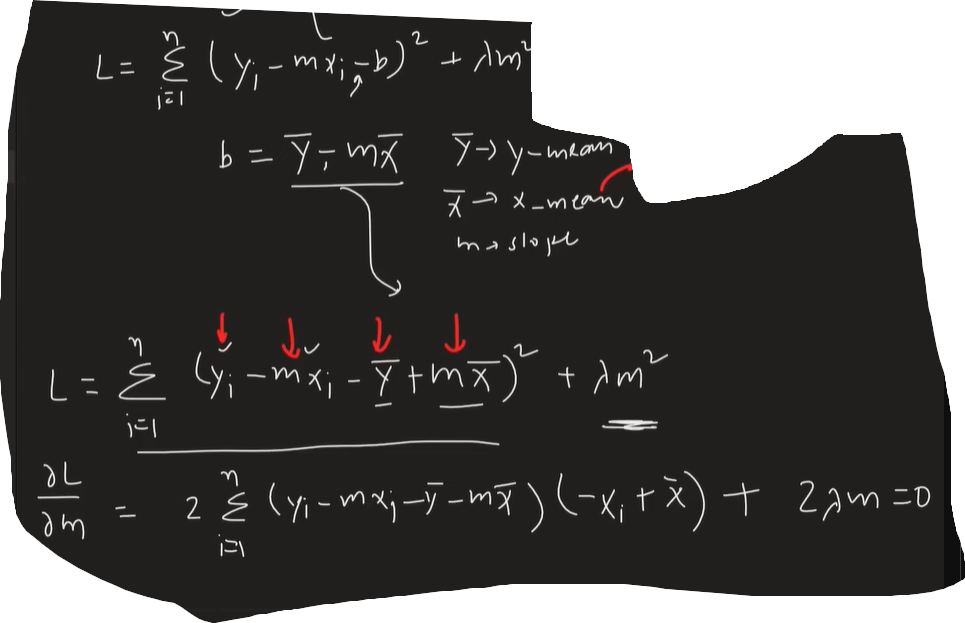

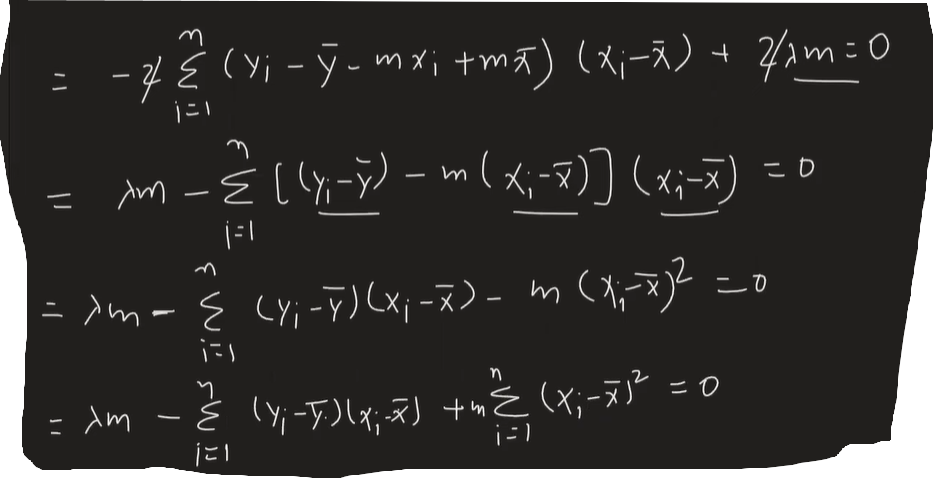

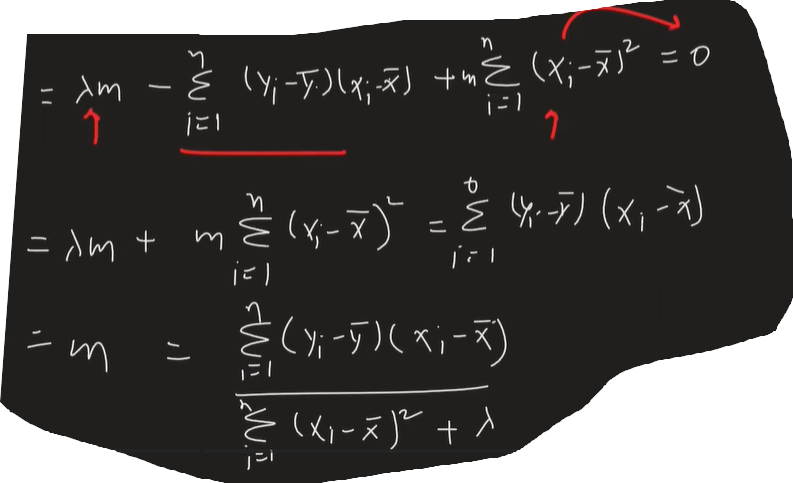

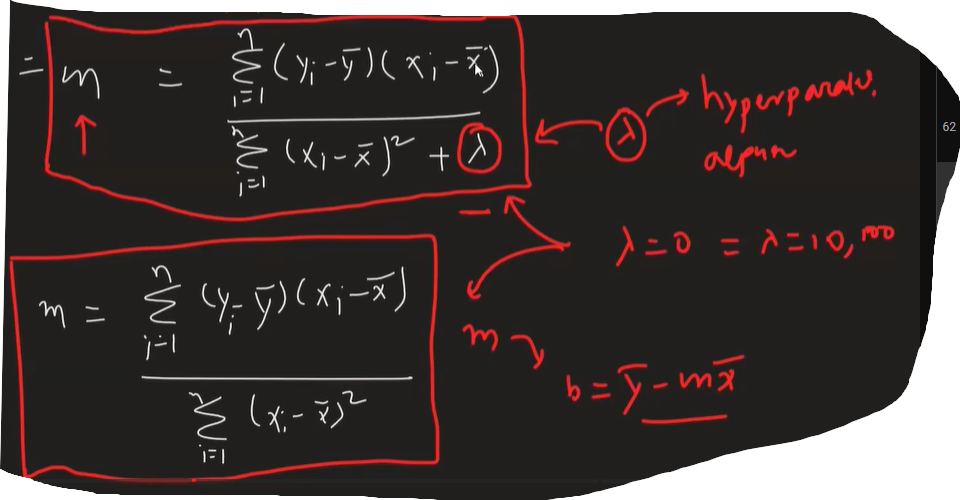

#**Code for Ridge reglurization from Scratch**

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np


In [36]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

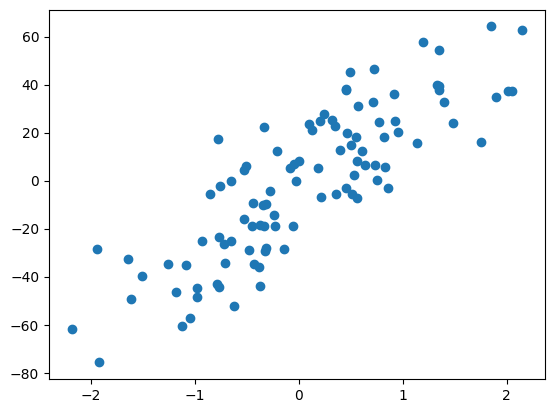

In [4]:
plt.scatter(X,y)

In [6]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [9]:
from sklearn.linear_model import Ridge

In [10]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235735


In [11]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


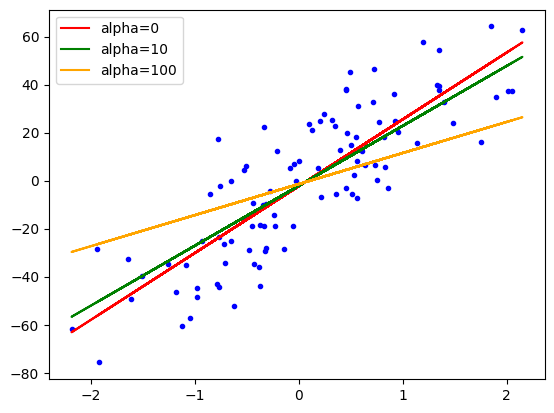

In [12]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

In [38]:
def linear_regression_fn(X,y,alpha=1):
  x_mean=X.mean()
  y_mean=y.mean()

  num = 0
  den = 0

  for i in range(X.shape[0]):
    num = num + (y[i]-y_mean)*(X[i]-x_mean)
    den = den + (X[i]-x_mean)*(X[i]-x_mean)

  m = num/(den+alpha)
  b = y_mean - m*x_mean

  #
  return m,b


In [39]:
linear_regression_fn(X,y,100)

(array([12.93442104]), array([-1.42484415]))

In [43]:
class myRidge:

  def __init__(self,alpha=0.1):

    self.alpha=alpha
    self.m=None
    self.b=None

  def fit(self,X_train,y_train):

    den = 0
    num = 0

    for i in range(X_train.shape[0]):

      num = num + (X_train[i]-X_train.mean())*(y_train[i]-y_train.mean())
      den = den + (X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())

    self.m = num/(den+self.alpha)
    self.b = y_train.mean() - (self.m*X_train.mean())
    print(self.m,self.b)


  def predict(X_test):
    pass






In [44]:
ridgereg=myRidge(alpha=100)

In [45]:
ridgereg.fit(X,y)

[12.93442104] [-1.42484415]


#**For N-d Data**

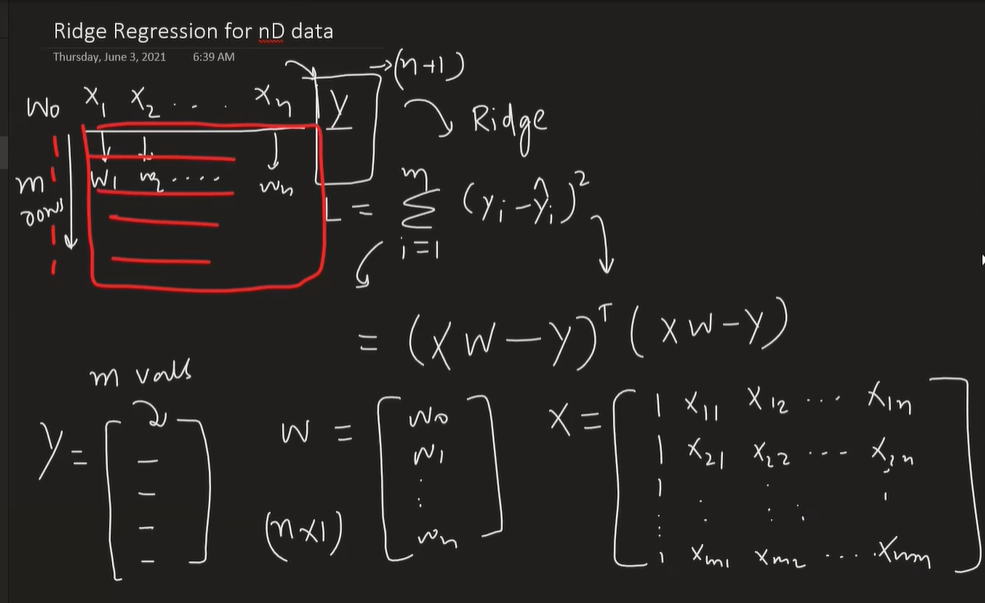

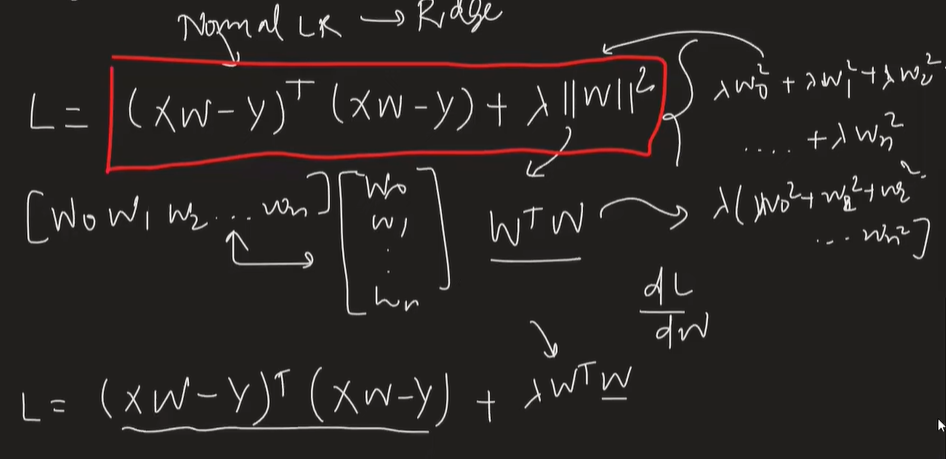

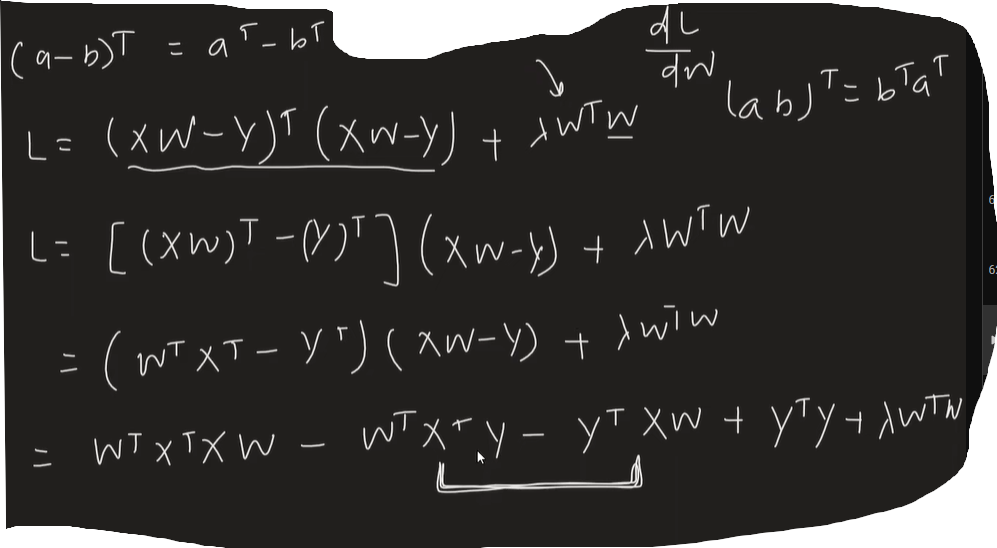

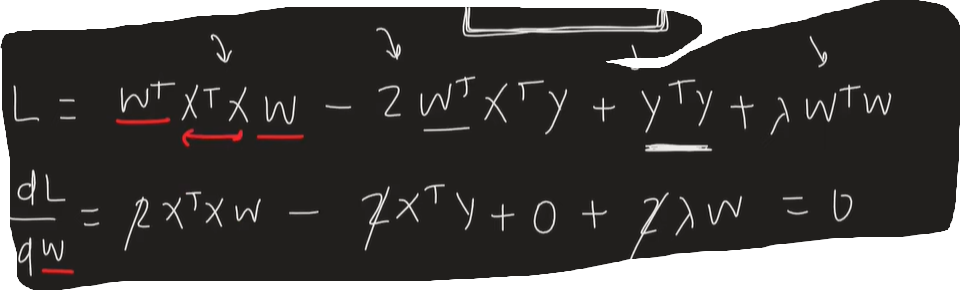

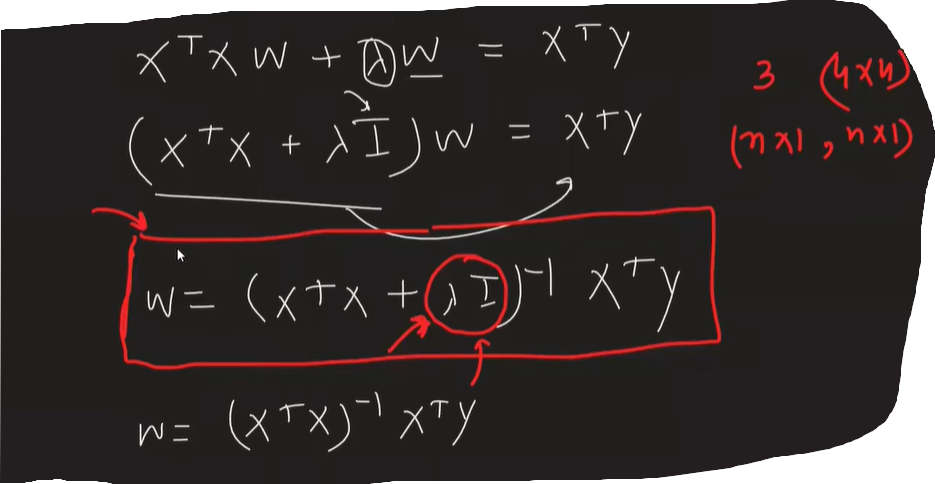

In [47]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
X,y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)
from sklearn.linear_model import Ridge
reg = Ridge(alpha=0.1,solver='cholesky')
reg.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [48]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4693128853309805

In [49]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [46]:
class MeraRidge:

    def __init__(self,alpha=0.1):

        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [50]:
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4693128853309805
[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.8905342560281
